<a href="https://colab.research.google.com/github/firatsayici/verimadenciligi/blob/main/imdbtask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
from google.colab import drive
import shutil
import os

local_file_path = "tmdb_movies.csv"
# ÖNEMLİ: Lütfen bu yolu Google Drive'daki dosyanızın gerçek konumuna güncelleyin.
# Örnek: '/content/drive/MyDrive/MyFolder/tmdb_movies.csv'
# Yanlış: 'https://drive.google.com/drive/folders/...' gibi bir URL kullanmayın.
drive_file_path = '/content/drive/MyDrive/archive/TMDB_all_movies.csv' # Lütfen bu satırı kendi dosyanızın doğru yerel yolu ile güncelleyin!

# Dosya yerel olarak mevcut değilse, Google Drive'dan kopyalamayı dene
if not os.path.exists(local_file_path):
    print(f"'{local_file_path}' yerel olarak bulunamadı. Google Drive'dan kopyalanmaya çalışılıyor...")
    try:
        # Google Drive'ı bağla
        drive.mount('/content/drive')
        # Dosyayı kopyala
        if os.path.exists(drive_file_path):
            shutil.copy(drive_file_path, local_file_path)
            print(f"'{drive_file_path}' başarıyla '{local_file_path}' konumuna kopyalandı.")
        else:
            print(f"Hata: '{drive_file_path}' Google Drive'da bulunamadı. Lütfen 'drive_file_path' değişkenini dosyanızın doğru yolu ile güncelleyin.")
    except Exception as e:
        print(f"Drive'ı bağlamaya veya dosyayı kopyalamaya çalışırken bir hata oluştu: {e}")
else:
    print(f"'{local_file_path}' yerel olarak bulundu. Google Drive'dan kopyalama atlanıyor.")

# Şimdi, CSV dosyasını okumayı dene
try:
    df = pd.read_csv(local_file_path)
    print("CSV dosyası başarıyla yüklendi.")
    print(df.head())
except FileNotFoundError:
    print(f"Hata: Kopyalama denemesinden sonra '{local_file_path}' hala bulunamadı. Lütfen dosyanın var olduğundan ve yolun doğru olduğundan emin olun.")
except Exception as e:
    print(f"CSV okunurken bir hata oluştu: {e}")

'tmdb_movies.csv' yerel olarak bulunamadı. Google Drive'dan kopyalanmaya çalışılıyor...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/archive/TMDB_all_movies.csv' başarıyla 'tmdb_movies.csv' konumuna kopyalandı.
CSV dosyası başarıyla yüklendi.
   id                             title  vote_average  vote_count    status  \
0   2                             Ariel           7.1       367.0  Released   
1   3               Shadows in Paradise           7.3       435.0  Released   
2   5                        Four Rooms           5.9      2816.0  Released   
3   6                    Judgment Night           6.5       369.0  Released   
4   8  Life in Loops (A Megacities RMX)           7.2        30.0  Released   

  release_date     revenue  runtime      budget    imdb_id  ...  \
0   1988-10-21         0.0     73.0         0.0  tt0094675  ...   
1   1986-10-17         0.0     74.0     

In [19]:
df = pd.read_csv("tmdb_movies.csv")
df.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,spoken_languages,cast,director,director_of_photography,writers,producers,music_composer,imdb_rating,imdb_votes,poster_path
0,2,Ariel,7.1,367.0,Released,1988-10-21,0.0,73.0,0.0,tt0094675,...,suomi,"Tarja Keinänen, Marja Packalén, Kari Helaseppä...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Aki Kaurismäki,NaN,7.4,9708.0,/ojDg0PGvs6R9xYFodRct2kdI6wC.jpg
1,3,Shadows in Paradise,7.3,435.0,Released,1986-10-17,0.0,74.0,0.0,tt0092149,...,"svenska, suomi, English","Ari Korhonen, Mari Rantasila, Erkki Rissanen, ...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Mika Kaurismäki,NaN,7.4,8583.0,/nj01hspawPof0mJmlgfjuLyJuRN.jpg
2,5,Four Rooms,5.9,2816.0,Released,1995-12-09,4257354.0,98.0,4000000.0,tt0113101,...,English,"Danny Verduzco, Quentin Tarantino, Marisa Tome...","Robert Rodriguez, Alexandre Rockwell, Quentin ...","Guillermo Navarro, Rodrigo García, Phil Parmet...","Quentin Tarantino, Alexandre Rockwell, Robert ...","Lawrence Bender, Quentin Tarantino, Alexandre ...",Combustible Edison,6.7,116724.0,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg
3,6,Judgment Night,6.5,369.0,Released,1993-10-15,12136938.0,109.0,21000000.0,tt0107286,...,English,"Nigel Gibbs, Lauren Robinson, Galyn Görg, Lyde...",Stephen Hopkins,Peter Levy,"Lewis Colick, Jere Cunningham","Gene Levy, Marilyn Vance, Lloyd Segan",Alan Silvestri,6.6,20989.0,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg
4,8,Life in Loops (A Megacities RMX),7.2,30.0,Released,2006-01-01,0.0,80.0,42000.0,tt0825671,...,"English, हिन्दी, 日本語, Pусский, Español",NaN,Timo Novotny,Wolfgang Thaler,"Timo Novotny, Michael Glawogger","Timo Novotny, Ulrich Gehmacher",NaN,8.1,285.0,/7ln81BRnPR2wqxuITZxEciCe1lc.jpg


In [20]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178437 entries, 0 to 1178436
Data columns (total 28 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id                       1178437 non-null  int64  
 1   title                    1178427 non-null  object 
 2   vote_average             1178437 non-null  float64
 3   vote_count               1178437 non-null  float64
 4   status                   1178437 non-null  object 
 5   release_date             1055257 non-null  object 
 6   revenue                  1178437 non-null  float64
 7   runtime                  1178437 non-null  float64
 8   budget                   1178437 non-null  float64
 9   imdb_id                  660775 non-null   object 
 10  original_language        1178437 non-null  object 
 11  original_title           1178428 non-null  object 
 12  overview                 998429 non-null   object 
 13  popularity               1178437 non-null 

,0
id,0
title,10
vote_average,0
vote_count,0
status,0
release_date,123180
revenue,0
runtime,0
budget,0
imdb_id,517662


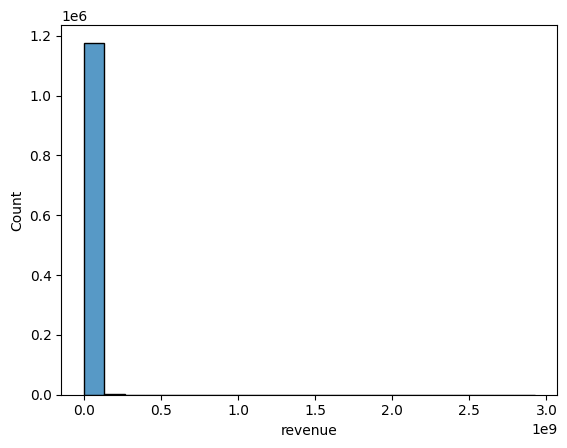

In [21]:
sns.histplot(df['revenue'])
plt.show()

In [22]:
df = df.dropna()
df = df.drop_duplicates()

In [24]:
df['ROI'] = df['revenue'] / df['budget']